In [1]:
import math
import time
from dataclasses import dataclass
from typing import Optional

import torch
import torch.nn as nn
import torch.nn.functional as F


import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader, Subset, TensorDataset


import os
os.chdir("/root/torch-jit")

In [13]:
device = "cuda" if torch.cuda.is_available() else "cpu"

def get_mnist_loader(batch_size: int) -> DataLoader:
    transform = transforms.Compose([transforms.ToTensor()])
    dataset = torchvision.datasets.MNIST(
        root="/root/torch-jit/data", train=True, download=True, transform=transform
    )
    pin = device == "cuda"
    return torch.utils.data.DataLoader(
        dataset, batch_size=batch_size, shuffle=True, drop_last=True, pin_memory=pin
    )

def get_synthetic_sequence_loader(
    batch_size: int,
    seq_len: int = 64,
    input_dim: int = 64,
    num_classes: int = 10,
    size: int = 4096,
    train: bool = True,
) -> DataLoader:
    """
    Generates a synthetic sequence dataset and wrap it in a DataLoader.
    """
    g = torch.Generator().manual_seed(123 if train else 321)
    x = torch.randn(size, seq_len, input_dim, generator=g)

    # Correlate labels with signal in first few features for learnability.
    logits = x[:, :, : min(input_dim, num_classes)].mean(dim=1)
    y = logits.argmax(dim=1) % num_classes

    ds = TensorDataset(x, y)
    return DataLoader(ds, batch_size=batch_size, shuffle=train)

In [ ]:
train_loader_seq = get_synthetic_sequence_loader(batch_size=128)
test_loader_seq = get_synthetic_sequence_loader(batch_size=128, train=False)

In [16]:
train_loader_img = get_mnist_loader(128)

In [5]:

from layers import ModelSpec, build_model

from torch_privacy import CustomPrivacyEngine, DPConfig

In [6]:
print(ModelSpec)

<class 'layers.ModelSpec'>


In [7]:
vit_model = build_model(ModelSpec(model_name="vit", seq_input_dim=64, seq_len=32, seq_hidden_dim=128, num_classes=10)).to("cuda")
dp_config = DPConfig(
    
    max_grad_norm=10.0,
    noise_multiplier=0.0,
    vmap_chunk_size=64,
    force_compile_mps=True,
)

engine = CustomPrivacyEngine(
    vit_model,
    config=dp_config
)

In [8]:
print(vit_model)

TinyViT(
  (patch_embed): Conv2d(1, 192, kernel_size=(4, 4), stride=(4, 4))
  (blocks): ModuleList(
    (0-3): 4 x TransformerBlock(
      (norm1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
      (attn): MultiHeadAttention(
        (q_proj): Linear(in_features=192, out_features=192, bias=True)
        (k_proj): Linear(in_features=192, out_features=192, bias=True)
        (v_proj): Linear(in_features=192, out_features=192, bias=True)
        (out_proj): Linear(in_features=192, out_features=192, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (norm2): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=192, out_features=768, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=768, out_features=192, bias=True)
      )
    )
  )
  (norm): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
  (head): Linear(in_features=192, out_features=10, bias=True)
)


In [14]:
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

def explain_compile():
    vit_model = build_model(ModelSpec(model_name="vit", seq_input_dim=64, seq_len=32, seq_hidden_dim=128, num_classes=10)).to(device)


    if not hasattr(torch, "_dynamo"):
        print("torch._dynamo is not available")
        return
    # Build a tiny batch to trace
    loader = get_mnist_loader(batch_size=4)

    x, y = next(iter(loader))
    x = x.to(device)
    y = y.to(device)

    params = {k: v.detach() for k, v in vit_model.named_parameters()}
    buffers = {k: v for k, v in vit_model.named_buffers()}
    
    compiled_step = engine.get_compiled_step("flat", F.cross_entropy)

    report = torch._dynamo.explain(
        compiled_step,
        params,
        buffers,
        (x, y),
        float(engine.config.max_grad_norm),
        float(engine.config.noise_multiplier),
        0.1,  # lr
    )
    print(report)

explain_compile()

100%|██████████| 9.91M/9.91M [00:01<00:00, 9.48MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 122kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.32MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.28MB/s]
/root/miniconda3/envs/myenv/lib/python3.10/unittest/mock.py:1370: FutureWarning: explain(f, *args, **kwargs) is deprecated, use explain(f)(*args, **kwargs) instead.  If you don't migrate, we may break your explain call in the future if your user defined kwargs conflict with future kwargs added to explain(f).
  return func(*newargs, **newkeywargs)


Graph Count: 1
Graph Break Count: 0
Op Count: 813
Break Reasons:
Ops per Graph:
  Ops 1:
    <function lazy_load_decompositions at 0x7c77b593e710>
    <built-in function getitem>
    <built-in function getitem>
    <function _vmap_increment_nesting at 0x7c77b593e5f0>
    <function _add_batch_dim at 0x7c77b593e4d0>
    <function _add_batch_dim at 0x7c77b593e4d0>
    <built-in method _saved_tensors_hooks_disable of pybind11_builtins.pybind11_detail_function_record_v1_system_libstdcpp_gxx_abi_1xxx_use_cxx11_abi_1 object at 0x7c782d75bf50>
    <built-in method _grad_increment_nesting of pybind11_builtins.pybind11_detail_function_record_v1_system_libstdcpp_gxx_abi_1xxx_use_cxx11_abi_1 object at 0x7c794d059df0>
    <built-in method _wrap_for_grad of pybind11_builtins.pybind11_detail_function_record_v1_system_libstdcpp_gxx_abi_1xxx_use_cxx11_abi_1 object at 0x7c794d059e70>
    <built-in method _wrap_for_grad of pybind11_builtins.pybind11_detail_function_record_v1_system_libstdcpp_gxx_abi_1xxx

In [20]:
import tqdm


def _sync_device(device):
    if device == "cuda" and torch.cuda.is_available():
        torch.cuda.synchronize()
    elif device == "mps" and hasattr(torch, "mps") and torch.backends.mps.is_available():
        torch.mps.synchronize()

def train(model, engine, loader, lr, num_epochs):
    model.train()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    stats_collection = []
    device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))

    _sync_device(device)
    start = time.perf_counter()

    for i in tqdm.tqdm(range(num_epochs), desc="Training"):
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            stats = engine.dp_step(x, y, optimizer, use_compile=True)
        _sync_device(device)

        stats_collection.append(stats)
    elapsed = time.perf_counter() - start
    return elapsed, stats_collection


elapsed, stats_collection = train(vit_model, engine, train_loader_img, lr=1e-3, num_epochs=1)
print(f"Training took {elapsed:.2f} seconds")

Training: 100%|██████████| 1/1 [00:17<00:00, 17.09s/it]

Training took 17.10 seconds


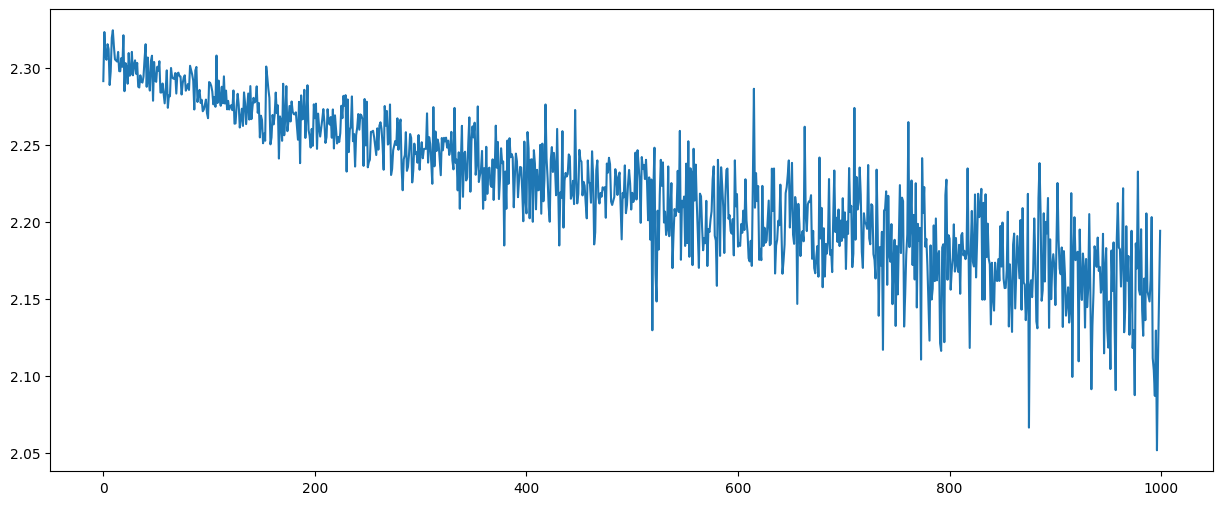

In [27]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(stats_collection))
train_loss = [s["loss"] for s in stats_collection]

# make the diagram bigger
plt.figure(figsize=(15, 6))
plt.plot(x, train_loss)